# Chicago Crime Analysis
## Requête 3 — Analyse temporelle & Forecasting
**Auteure : Léora**

**Objectif :** Analyser l'évolution temporelle des crimes à Chicago et prévoir 
leur tendance future grâce au modèle de forecasting Prophet.

---

In [115]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet

### Chargement du dataset

In [116]:
# Fonction de chargement du dataset
# Input : chemin vers le fichier CSV
# Output : dataframe pandas avec la colonne Date parsée en datetime
def load_data(file_path):
    df = pd.read_csv(file_path)
    df["Date"] = pd.to_datetime(df["Date"], format='mixed')
    print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    return df

In [117]:
filepath="../data/chicago_crime.csv"
df = load_data(filepath)
df.head()

Dataset chargé : 949 lignes × 20 colonnes


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,Ward,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14216537,JK278149,2026-06-01 21:58:00,007XX W 31ST ST,0560,ASSAULT,SIMPLE,DRUG STORE,True,False,915,11,08A,1171697.0,1884328.0,2026,2026 Jun 09 04:13:19 PM,"41,83805499","-87,645458414",POINT (-87.645458414 41.83805499)
1,14203870,JK262663,2026-05-20 17:50:00,007XX W 31ST ST,0850,THEFT,ATTEMPT THEFT,SIDEWALK,False,False,915,11,06,1171668.0,1884327.0,2026,2026 May 28 03:42:02 PM,"41,838052883","-87,645564858",POINT (-87.645564858 41.838052883)
2,14178251,JK231486,2026-04-25 22:55:00,007XX W 31ST ST,0860,THEFT,RETAIL THEFT,CONVENIENCE STORE,False,False,915,11,06,1171697.0,1884328.0,2026,2026 May 03 03:43:04 PM,"41,83805499","-87,645458414",POINT (-87.645458414 41.83805499)
3,14134795,JK178608,2026-03-12 15:07:00,007XX W 31ST ST,0560,ASSAULT,SIMPLE,STREET,False,False,915,11,08A,1171697.0,1884328.0,2026,2026 Mar 20 03:43:34 PM,"41,83805499","-87,645458414",POINT (-87.645458414 41.83805499)
4,14114764,JK154429,2026-02-18 18:30:00,007XX W 31ST ST,0820,THEFT,$500 AND UNDER,SMALL RETAIL STORE,False,False,915,11,06,1171668.0,1884327.0,2026,2026 Mar 14 03:41:39 PM,"41,838052883","-87,645564858",POINT (-87.645564858 41.838052883)


## Analyse temporelle

### Évolution mensuelle des crimes

Ce graphique représente le nombre de crimes commis à Bridgeport (Chicago) 
répartis par mois sur toute la période disponible (2002-2026).

**Calcul :** Les données sont agrégées par mois grâce à la fonction 
`monthly_aggregation()` qui groupe les incidents par année et mois.

**Interprétation :** On observe un pic en juin 2005 avec 11 crimes. 
Après 2006, le nombre de crimes tend à diminuer globalement. 
La criminalité reste variable d'un mois à l'autre mais stable sur le long terme,
avec une légère saisonnalité visible.

In [118]:
# Fonction d'agrégation des crimes par mois
# input : Dataframe pandas avec colonne Date en datetime
# Output : dataframe avec le nombre de crimes par mois

def monthly_aggregation(df):
    df["YearMonth"] = df["Date"].dt.to_period("M")
    monthly = df.groupby("YearMonth").size().reset_index(name="Crime_Count")
    monthly["YearMonth"] = monthly["YearMonth"].dt.to_timestamp()
    return monthly

monthly = monthly_aggregation(df)
monthly.head()

,YearMonth,Crime_Count
0,2002-04-01,1
1,2002-05-01,4
2,2002-06-01,1
3,2002-07-01,2
4,2002-08-01,2


In [119]:
# Fonction de visualisation de l'évolution mensuelle des crimes
# Input : dataframe mensuel avec colonnes YearMonth et Crime_Count
# Output : figure Plotly

def plot_monthly_crimes(monthly):
    # Trouver le mois avec le plus de crimes
    idx_max = monthly["Crime_Count"].idxmax()
    pic = monthly.loc[idx_max]
    
    plot = px.line(
        monthly,
        x="YearMonth",
        y="Crime_Count",
        title="Evolution mensuelle des crimes à Chicago",
        labels={"YearMonth": "Année", "Crime_Count": "Nombre de crimes"}
    )
    
    # Annoter le pic maximum sur le graphique
    plot.add_annotation(
        x=pic["YearMonth"],
        y=pic["Crime_Count"],
        text=f"Pic : {pic['Crime_Count']} crimes ({pic['YearMonth'].strftime('%b %Y')})",
        showarrow=True,
        arrowhead=2,
        yshift=10
    )
    return plot

fig_monthly = plot_monthly_crimes(monthly)
fig_monthly.show()

### Évolution annuelle des crimes

Ce graphique représente le nombre total de crimes commis à Bridgeport (Chicago) 
par année sur la période 2002-2026.

**Calcul :** Les données sont agrégées par année grâce à la fonction 
`yearly_aggregation()` qui groupe les incidents par année et compte le nombre 
d'occurrences.

**Interprétation :** On observe un pic record en 2011 avec 66 crimes. 
Après cette année, la criminalité suit une tendance globalement baissière 
jusqu'en 2022. La chute observée en 2026 s'explique par le fait que l'année 
n'est pas encore terminée au moment de l'analyse.

In [120]:
# Fonction d'agrégation des crimes par année
# input : Dataframe pandas avec colonne Date en datetime
# Output : dataframe avec le nombre de crimes par année
def yearly_aggregation(df):
    df["Year"] = df["Date"].dt.year
    yearly = df.groupby("Year").size().reset_index(name="Crime_Count")
    return yearly

yearly = yearly_aggregation(df)
yearly.head()

,Year,Crime_Count
0,2002,20
1,2003,35
2,2004,53
3,2005,57
4,2006,25


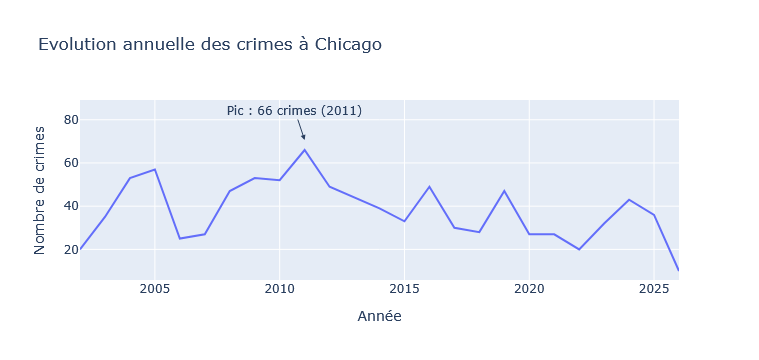

In [121]:
# Fonction de visualisation de l'évolution annuelle des crimes
# Input : dataframe annuel avec colonnes Year et Crime_Count
# Output : figure Plotly

def plot_yearly_crimes(yearly):
    # Trouver l'année avec le plus de crimes
    idx_max = yearly["Crime_Count"].idxmax()
    pic = yearly.loc[idx_max]
    
    plot = px.line(
        yearly,
        x="Year",
        y="Crime_Count",
        title="Evolution annuelle des crimes à Chicago",
        labels={"Year": "Année", "Crime_Count": "Nombre de crimes"}
    )
    
    # Annoter le pic maximum sur le graphique
    plot.add_annotation(
        x=pic["Year"],
        y=pic["Crime_Count"],
        text=f"Pic : {pic['Crime_Count']} crimes ({pic['Year']})",
        showarrow=True,
        arrowhead=2,
        yshift=10
    )
    return plot

fig_yearly = plot_yearly_crimes(yearly)
fig_yearly.show()

### Prévision du nombre de crimes avec Prophet

Ce graphique représente l'évolution passée et la prévision future du nombre 
de crimes mensuels à Bridgeport (Chicago) sur les 12 prochains mois.

**Calcul :** Le modèle Prophet (développé par Facebook) est entraîné sur 
les données historiques mensuelles. Il prédit automatiquement la tendance 
et la saisonnalité à partir des données passées.

**Indicateurs :**
- `yhat` : valeur prédite (nombre de crimes attendu)
- `yhat_lower` : borne basse de l'intervalle de confiance (scénario optimiste)
- `yhat_upper` : borne haute de l'intervalle de confiance (scénario pessimiste)

**Interprétation :** Le modèle prédit que la criminalité restera stable, 
avec une légère tendance à la baisse. Le nombre de crimes continuera de 
varier selon les mois (saisonnalité) mais restera globalement stable d'une 
année à l'autre.

In [122]:
df_prophet = monthly.rename(columns={"YearMonth": "ds", "Crime_Count": "y"})

In [123]:
# Fonction de forecasting avec Prophet
# Input : dataframe avec colonnes ds (dates) et y (nombre de crimes)
# Output : dataframe de prévisions avec yhat, yhat_lower, yhat_upper
def run_prophet(df_prophet):
    model = Prophet()
    model.fit(df_prophet)
    future = model.make_future_dataframe(periods=12, freq="MS")
    forecast = model.predict(future)
    return model, forecast
model, forecast = run_prophet(df_prophet)

22:10:54 - cmdstanpy - INFO - Chain [1] start processing
22:10:54 - cmdstanpy - INFO - Chain [1] done processing


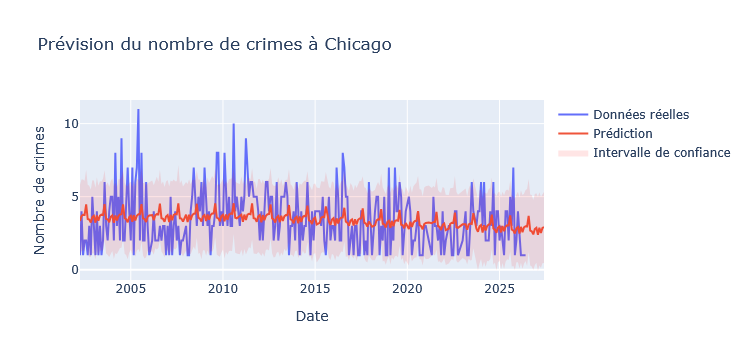

In [124]:
# Fonction de forecasting avec Prophet
# Input : forecast prophet et dataframe adapté
# Output : graphique plotly
def plot_forecast(forecast, df_prophet):
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=df_prophet["ds"], y=df_prophet["y"], name="Données réelles", mode="lines"))
    fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat"], name="Prédiction", mode="lines"))
    fig.add_trace(go.Scatter(
        x=pd.concat([forecast["ds"], forecast["ds"][::-1]]),
        y=pd.concat([forecast["yhat_upper"], forecast["yhat_lower"][::-1]]),
        fill="toself",
        fillcolor="rgba(255,0,0,0.1)",
        line=dict(color="rgba(255,255,255,0)"),
        name="Intervalle de confiance"
    ))

    fig.update_layout(
        title="Prévision du nombre de crimes à Chicago",
        xaxis_title="Date",
        yaxis_title="Nombre de crimes"
    )
    return fig

plot_forecast(forecast, df_prophet).show()

### Composantes du modèle Prophet

Ces graphiques décomposent la prévision en deux éléments distincts.

**Tendance :** La criminalité suit une tendance globalement descendante 
depuis 2011, confirmant la baisse observée sur le graphique annuel.

**Saisonnalité annuelle :** On observe une variation cyclique au cours 
de l'année avec un pic en juillet (été) et un creux en janvier/février (hiver). 
Cela suggère que la criminalité est influencée par les saisons.

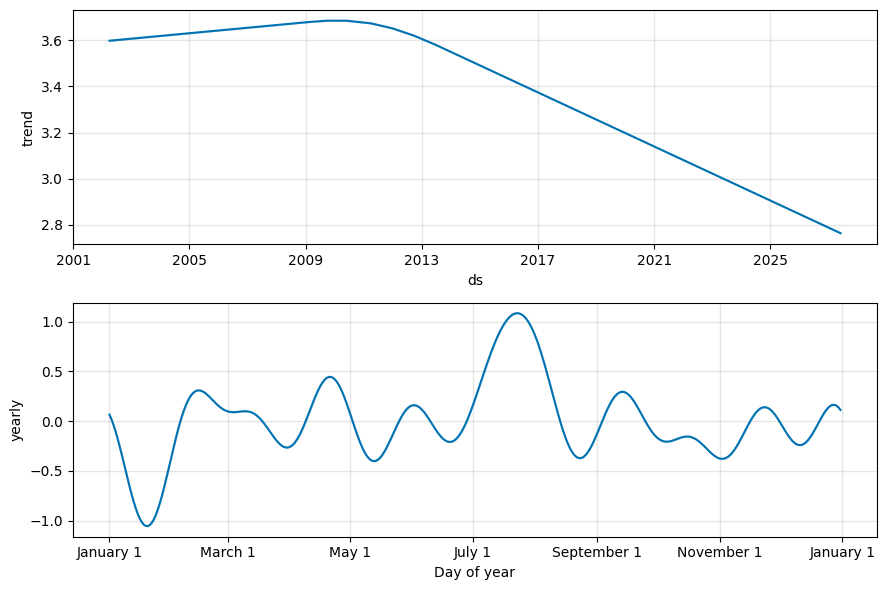

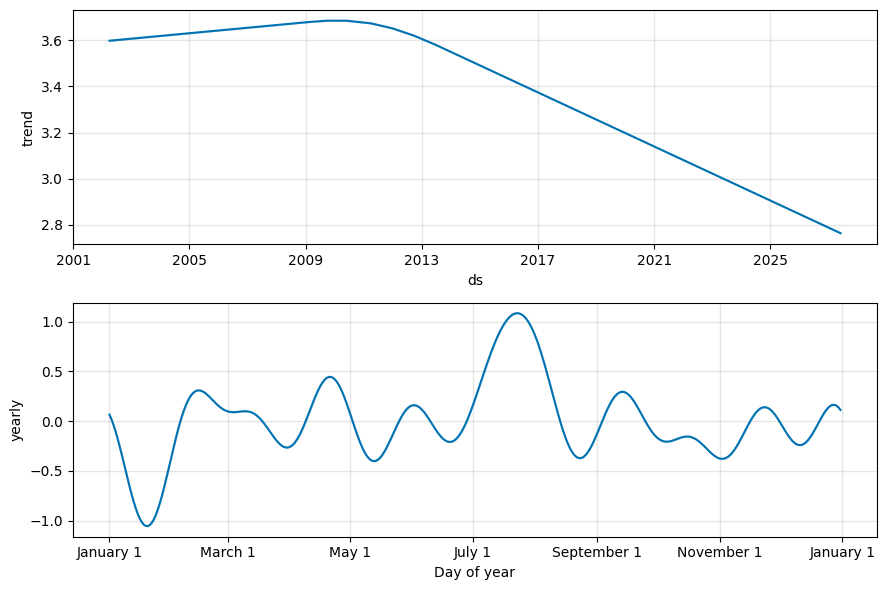

In [125]:
# Fonction de visualisation des composantes Prophet (tendance + saisonnalité)
# Input : modèle Prophet entraîné et dataframe de prévisions
# Output : figure matplotlib
def plot_prophet_components(model, forecast):
    fig = model.plot_components(forecast)
    return fig

plot_prophet_components(model, forecast)

Dataset chargé : 949 lignes × 20 colonnes


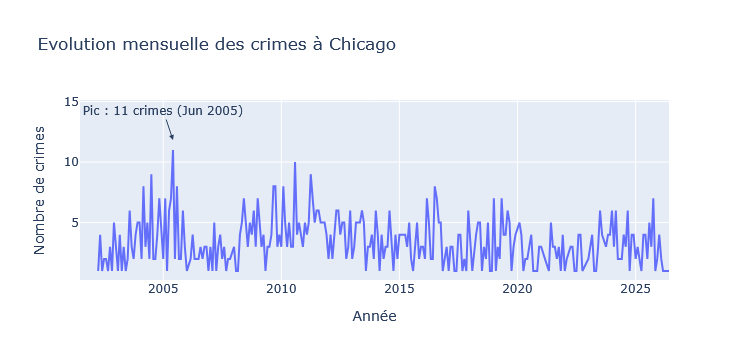

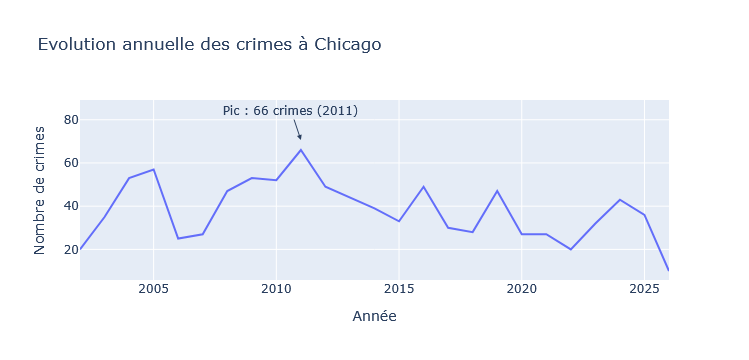

22:10:55 - cmdstanpy - INFO - Chain [1] start processing
22:10:55 - cmdstanpy - INFO - Chain [1] done processing


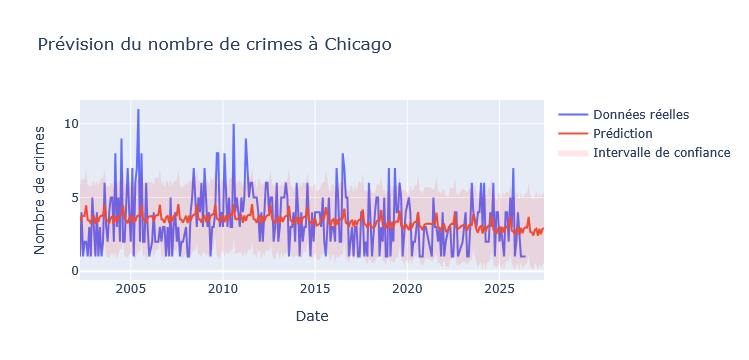

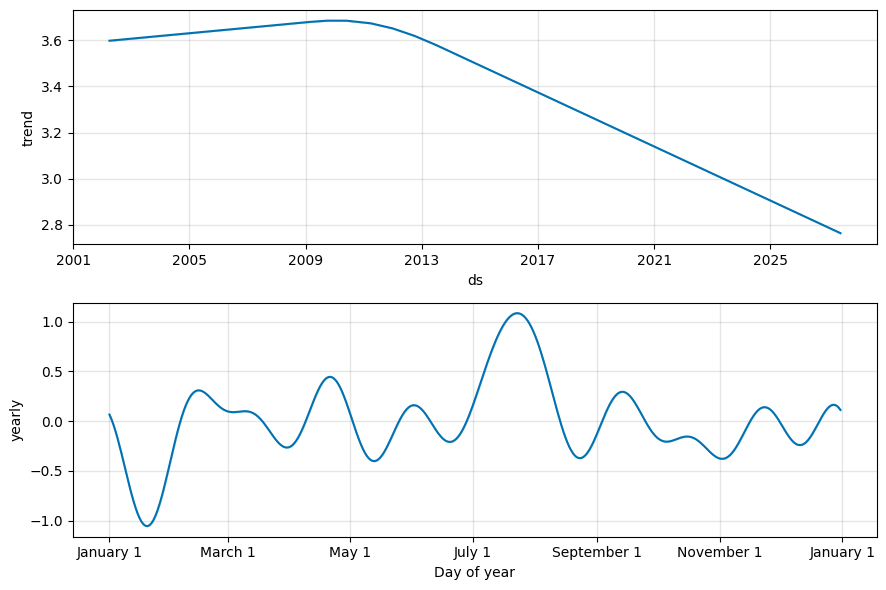

In [126]:
if __name__ == "__main__":
    # Étape 1 : Chargement
    df = load_data("../data/chicago_crime.csv")
    
    # Étape 2 : Analyse temporelle
    monthly = monthly_aggregation(df)
    fig_monthly = plot_monthly_crimes(monthly)
    fig_monthly.show()
    
    yearly = yearly_aggregation(df)
    fig_yearly = plot_yearly_crimes(yearly)
    fig_yearly.show()
    
    # Étape 3 : Forecasting
    df_prophet = monthly.rename(columns={"YearMonth": "ds", "Crime_Count": "y"})
    model, forecast = run_prophet(df_prophet)
    
    fig_forecast = plot_forecast(forecast, df_prophet)
    fig_forecast.show()
    
    plot_prophet_components(model, forecast)